In [20]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [21]:
# Quiz

G = nx.Graph()

left_hub = "B"
left_cluster = ["L1", "L2", "L3", "L4"]

right_hub = "R0"
right_cluster = ["R1", "R2", "R3", "C"]

bridge = "A"

G.add_node(left_hub)
G.add_nodes_from(left_cluster)

G.add_node(right_hub)
G.add_nodes_from(right_cluster)

G.add_node(bridge)

for n in left_cluster:
    G.add_edge(left_hub, n)

for n in right_cluster:
    G.add_edge(right_hub, n)

G.add_edge(left_hub, bridge)
G.add_edge(bridge, right_hub)

print("Nodes:", G.nodes())
print("Edges:", G.edges())


Nodes: ['B', 'L1', 'L2', 'L3', 'L4', 'R0', 'R1', 'R2', 'R3', 'C', 'A']
Edges: [('B', 'L1'), ('B', 'L2'), ('B', 'L3'), ('B', 'L4'), ('B', 'A'), ('R0', 'R1'), ('R0', 'R2'), ('R0', 'R3'), ('R0', 'C'), ('R0', 'A')]


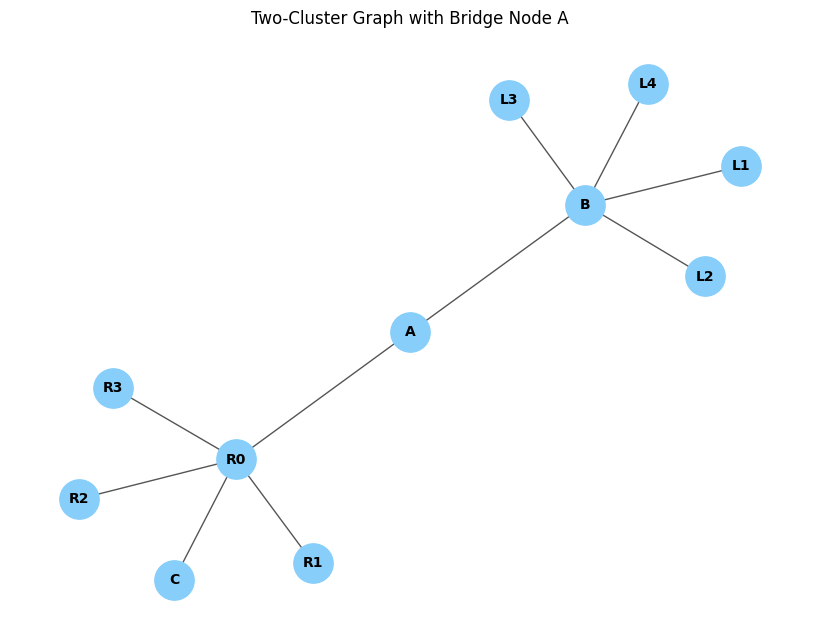

In [22]:


pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(8, 6))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=800,
    node_color="#87CEFA",
    font_size=10,
    font_weight="bold",
    edge_color="#555"
)

plt.title("Two-Cluster Graph with Bridge Node A")
plt.show()


In [23]:
nx.betweenness_centrality(G, normalized=True)

{'B': 0.6666666666666667,
 'L1': 0.0,
 'L2': 0.0,
 'L3': 0.0,
 'L4': 0.0,
 'R0': 0.6666666666666667,
 'R1': 0.0,
 'R2': 0.0,
 'R3': 0.0,
 'C': 0.0,
 'A': 0.5555555555555556}

In [ ]:
# Synthetic networks

n1 = 100
p1 = 0.05
synth_G1 = nx.erdos_renyi_graph(n1, p1)

print("synth_G1:", synth_G1.number_of_nodes(), "nodes,", synth_G1.number_of_edges(), "edges")


n2 = 100
m2 = 2
synth_G2 = nx.barabasi_albert_graph(n2, m2)

print("synth_G2:", synth_G2.number_of_nodes(), "nodes,", synth_G2.number_of_edges(), "edges")


n3 = 100
m3 = 200 
synth_G3 = nx.gnm_random_graph(n3, m3)

print("synth_G3:", synth_G3.number_of_nodes(), "nodes,", synth_G3.number_of_edges(), "edges")



synth_G1: 100 nodes, 234 edges
synth_G2: 100 nodes, 196 edges
synth_G3: 100 nodes, 200 edges


In [25]:
# Internet networks

net_G1 = nx.read_adjlist("../data/TutorialB/p2p-Gnutella05.txt", nodetype=int)
print(net_G1)

net_G2 = nx.read_adjlist("../data/TutorialB/p2p-Gnutella06.txt", nodetype=int)
print(net_G2)

net_G3 = nx.read_adjlist("../data/TutorialB/p2p-Gnutella09.txt", nodetype=int)
print(net_G3)

Graph with 8846 nodes and 31839 edges
Graph with 8717 nodes and 31525 edges
Graph with 8114 nodes and 26013 edges


In [ ]:
# Functions

def plot_measures(G, name, plot_id):
    if G.is_directed():
        degrees = dict(G.in_degree())
    else:
        degrees = dict(G.degree())
    
    n = G.number_of_nodes()
    norm_deg = {node: degrees[node] / (n - 1) for node in G.nodes()}
    
    pr = nx.pagerank(G, max_iter=100, tol=1e-06)
    
    x = np.array([pr[n] for n in G.nodes()])
    y = np.array([norm_deg[n] for n in G.nodes()])
    
    plt.figure(figsize=(6, 5))
    plt.scatter(x, y, alpha=0.7)
    
    plt.title(
        f"Plot {plot_id}: PageRank vs Normalized Degree\n"
        f"Scatter plot for network {name}",
        fontsize=12
    )
    
    plt.xlabel("PageRank")
    plt.ylabel("Normalized Degree")
    plt.grid(True, alpha=0.3)
    
    # My path = ../data/TutorialB/plots/ 
    # Write to workdir
    filename = f"plot_{plot_id:02d}_{name}_measures.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close()




def plot_network(G, name, plot_id):
    if G.is_directed():
        degrees = dict(G.in_degree())
    else:
        degrees = dict(G.degree())
    
    sizes = np.array([degrees[n] for n in G.nodes()])
    sizes = 300 * (sizes / sizes.max()) + 50
    
    pr = nx.pagerank(G, max_iter=100, tol=1e-06)
    pr_values = np.array([pr[n] for n in G.nodes()])

    pos = nx.spring_layout(G, seed=42)
    
    plt.figure(figsize=(7, 6))
    nodes = nx.draw_networkx_nodes(
        G, pos,
        node_size=sizes,
        node_color=pr_values,
        cmap="coolwarm"
    )
    nx.draw_networkx_edges(G, pos, alpha=0.4)
    
    plt.title(
        f"Plot {plot_id}: Network Visualization ({name})\n"
        f"Node color = PageRank, Node size = Degree",
        fontsize=12
    )
    
    plt.colorbar(nodes, label="PageRank")
    plt.axis("off")

    # My path = ../data/TutorialB/plots/ 
    # Write to workdir
    filename = f"plot_{plot_id:02d}_{name}_network.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close()





In [36]:
graphs = [
    ("synth_G1", synth_G1),
    ("synth_G2", synth_G2),
    ("synth_G3", synth_G3),
    ("net_G1",   net_G1),
    ("net_G2",   net_G2),
    ("net_G3",   net_G3),
]

plot_id = 1

for name, G in graphs:
    plot_measures(G, name, plot_id)
    plot_id += 1
    plot_network(G, name, plot_id)
    plot_id += 1

